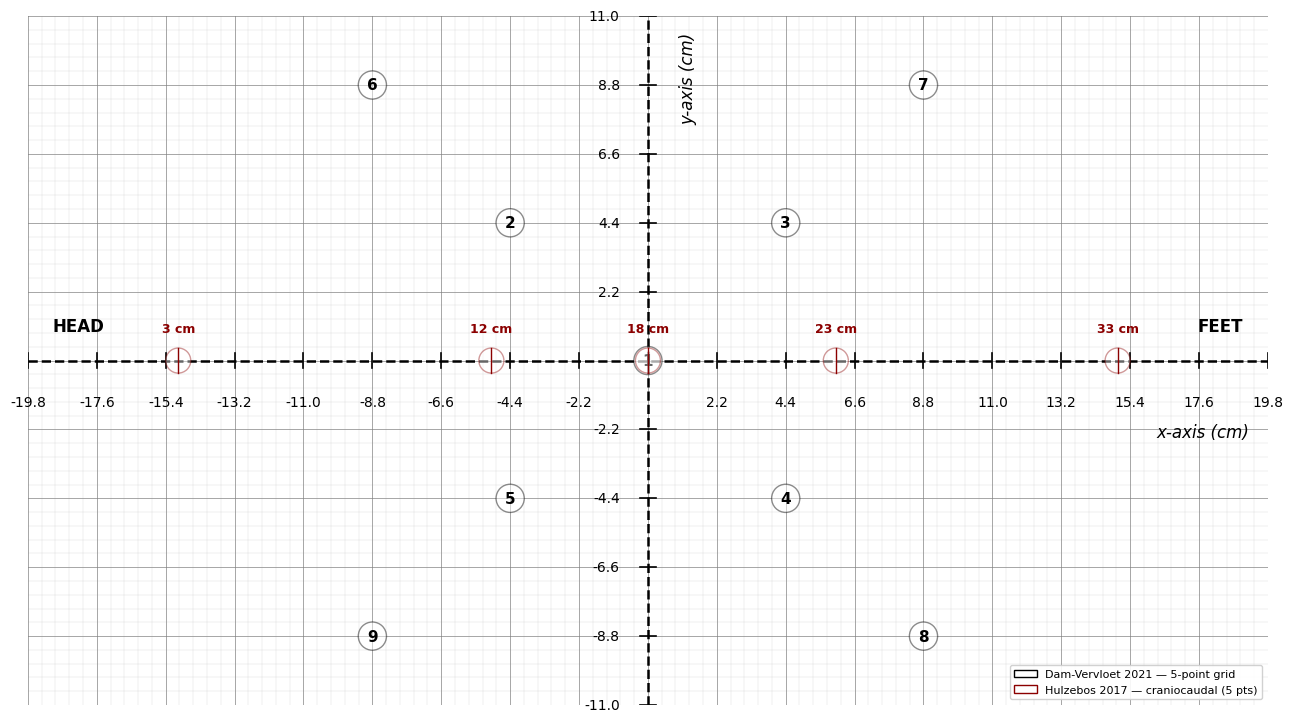

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Ellipse

X_MIN, X_MAX = -19.8, 19.8
Y_MIN, Y_MAX = -11.0, 11.0

fig, ax = plt.subplots(figsize=(16, 9))

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)

ax.set_aspect('equal')
ax.axis('off')

minor_step = 0.44
major_step = 2.2

# minor grid
x = X_MIN
while x <= X_MAX:
    if abs((x / major_step) - round(x / major_step)) > 0.01:
        ax.axvline(
            x,
            color='lightgray',
            linewidth=0.35,
            alpha=0.7,
            zorder=0
        )
    x += minor_step

y = Y_MIN
while y <= Y_MAX:
    if abs((y / major_step) - round(y / major_step)) > 0.01:
        ax.axhline(
            y,
            color='lightgray',
            linewidth=0.35,
            alpha=0.7,
            zorder=0
        )
    y += minor_step


# major grid
x = X_MIN
while x <= X_MAX:
    ax.axvline(
        x,
        color='gray',
        linewidth=0.7,
        alpha=0.7,
        zorder=0
    )
    x += major_step

y = Y_MIN
while y <= Y_MAX:
    ax.axhline(
        y,
        color='gray',
        linewidth=0.7,
        alpha=0.7,
        zorder=0
    )
    y += major_step

ax.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.8,
    zorder=1
)

ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.8,
    zorder=1
)


tick_values_x = [
    -19.8, -17.6, -15.4, -13.2, -11.0,
    -8.8, -6.6, -4.4, -2.2,
     2.2,  4.4,  6.6,  8.8,
    11.0, 13.2, 15.4, 17.6, 19.8
]

tick_values_y = [
    -11.0, -8.8, -6.6, -4.4, -2.2,
     2.2,  4.4,  6.6,  8.8, 11.0
]

# x-axis ticks
for x in tick_values_x:

    ax.plot(
        [x, x],
        [-0.25, 0.25],
        color='black',
        linewidth=1.2,
        zorder=2
    )

    ax.text(
        x,
        -1.1,
        f"{x:.1f}",
        ha='center',
        va='top',
        fontsize=10
    )

# y-axis ticks
for y in tick_values_y:

    ax.plot(
        [-0.25, 0.25],
        [y, y],
        color='black',
        linewidth=1.2,
        zorder=2
    )

    ax.text(
        -0.9,
        y,
        f"{y:.1f}",
        ha='right',
        va='center',
        fontsize=10
    )


ax.text(
    19.2,
    -2.0,
    'x-axis (cm)',
    ha='right',
    va='top',
    fontsize=12,
    style='italic'
)

ax.text(
    1.0,
    10.5,
    'y-axis (cm)',
    ha='left',
    va='top',
    fontsize=12,
    style='italic',
    rotation=90
)


ax.text(
    19.0,
    0.8,
    'FEET',
    ha='right',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    -19.0,
    0.8,
    'HEAD',
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)


points = {
    '1': (0.0, 0.0),
    '2': (-4.4, 4.4),
    '3': (4.4, 4.4),
    '4': (4.4, -4.4),
    '5': (-4.4, -4.4),
    '6': (-8.8, 8.8),
    '7': (8.8, 8.8),
    '8': (8.8, -8.8),
    '9': (-8.8, -8.8),
}

for label, (px, py) in points.items():

    ax.add_patch(
        Circle(
            (px, py),
            0.45,
            facecolor='white',
            edgecolor='black',
            linewidth=1.0,
            alpha=0.45,
            zorder=5
        )
    )

    ax.text(
        px,
        py,
        label,
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        zorder=6
    )


cc_points = {
    '3 cm': (-15, 0),
    '12 cm': (-5, 0),
    '18 cm': (0.0, 0),
    '23 cm': (6, 0),
    '33 cm': (15, 0),
}

for label, (px, py) in cc_points.items():

    # red CC marker
    ax.add_patch(
        Circle(
            (px, py),
            0.4,
            facecolor='white',
            edgecolor='darkred',
            linewidth=1.0,
            alpha=0.4,
            zorder=7
        )
    )

    ax.plot(
        [px, px],
        [py - 0.4, py + 0.4],
        color='darkred',
        linewidth=1.0,
        zorder=8
    )

    ax.text(
        px,
        py + 0.8,
        label,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='darkred'
    )

ax.legend(
    handles=[

        mpatches.Patch(
            facecolor='white',
            edgecolor='black',
            label='Dam-Vervloet 2021 — 5-point grid'
        ),

        mpatches.Patch(
            facecolor='white',
            edgecolor='darkred',
            label='Hulzebos 2017 — craniocaudal (5 pts)'
        ),
    ],
    loc='lower right',
    fontsize=8,
    framealpha=0.9
)



plt.savefig(
    'grid_final.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1
)

plt.savefig(
    'grid_final.pdf',
    bbox_inches='tight',
    pad_inches=0.1
)

plt.show()